<a href="https://colab.research.google.com/github/danielgonzalez222-crypto/taller-inteligencia-artificial-/blob/main/Taller_Regresi%C3%B3n_Bicicletas_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Objetivo: Aprender a aplicar regresión lineal para predecir el número de bicicletas alquiladas en un día.
===================================================
#1. Introducción
===================================================

Pregunta: ¿Qué tipo de problemas se pueden resolver con regresión lineal?

La regresión lineal sirve para predecir valores numéricos, como el precio de una casa, la cantidad de bicicletas alquiladas o el salario de una persona, usando variables que influyen en ese resultado. Es útil cuando hay una relación más o menos directa entre los datos.

#2. Carga de Dataset

In [ ]:
#Importa el/los módulo(s) pandas as pd para usarlos en el análisis.
import pandas as pd
# Obtiene el dataset de url externa
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
# Lee un archivo CSV y lo carga en un DataFrame de Pandas.
bike_data = pd.read_csv("daily-bike-share.csv")

--2025-10-18 16:35:32--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv.1’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.01s   

2025-10-18 16:35:33 (4.52 MB/s) - ‘daily-bike-share.csv.1’ saved [48800/48800]



In [ ]:
# Muestra las primeras 5 filas del dataset
bike_data.head()

# Muestra información general del dataset
bike_data.info()

# Genera una tabla con la descripción estadística de cada campo
bike_data.describe()

# Descripción de cada campo y su significado (comentarios para documentación)
# 'day': Fecha del registro.
# 'season': Estación del año (1: invierno, 2: primavera, 3: verano, 4: otoño).
# 'year': Año del registro (0: 2011, 1: 2012).
# 'month': Mes del año (1 a 12).
# 'holiday': Si fue día festivo (0: no, 1: sí).
# 'weekday': Día de la semana (0: domingo, 6: sábado).
# 'workingday': Si fue día laboral (0: no, 1: sí).
# 'weather': Condición climática (1: despejado, 2: nublado, 3: lluvia ligera, 4: lluvia fuerte).
# 'temp': Temperatura normalizada (0 a 1).
# 'atemp': Sensación térmica normalizada (0 a 1).
# 'humidity': Humedad relativa (0 a 1).
# 'windspeed': Velocidad del viento normalizada (0 a 1).
# 'casual': Usuarios ocasionales.
# 'registered': Usuarios registrados.
# 'count': Total de bicicletas alquiladas (variable objetivo).

# Pregunta: ¿Qué variable queremos predecir?
# Respuesta: La variable que queremos predecir es 'count', que representa el total de bicicletas alquiladas por día.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  rentals     731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


In [ ]:

import pandas as pd
# Carga el archivo CSV en un DataFrame
bike_data = pd.read_csv("daily-bike-share.csv")
#Ver nombre de las columnas
print(bike_data.columns)
# Extrae el día del mes desde la columna 'date' (formato de fecha)
bike_data['day_of_month'] = pd.to_datetime(bike_data['dteday']).dt.day

# Muestra las primeras 25 filas del dataset con la nueva columna
bike_data.head(25)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'rentals'],
      dtype='object')


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,day_of_month
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,2
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,3
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,4
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,5
5,6,1/6/2011,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,6
6,7,1/7/2011,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,7
7,8,1/8/2011,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,8
8,9,1/9/2011,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,9
9,10,1/10/2011,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,10


#3. Preparación de datos

In [ ]:
# Definir las características numéricas relevantes del dataset
features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
            'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

# Seleccionar la variable objetivo (label)
label = 'rentals'

# Mostrar estadísticas descriptivas de las variables numéricas y el objetivo
bike_data[features + [label]].describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


#4.Gráfica de datos

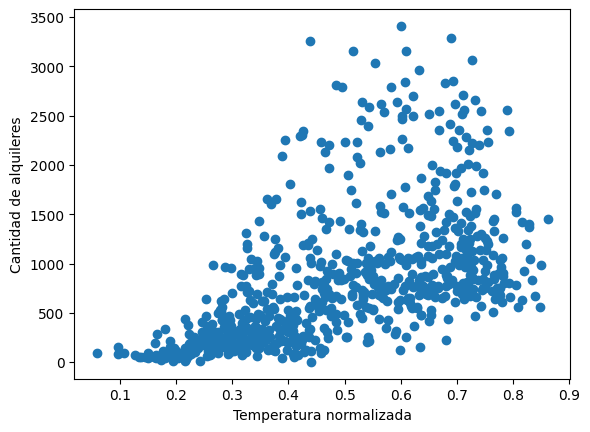

In [ ]:
# TODO: Grafica una dispersión de temperatura vs rentals
import matplotlib.pyplot as plt

plt.scatter(bike_data['temp'], bike_data['rentals'])
plt.xlabel('Temperatura normalizada')
plt.ylabel('Cantidad de alquileres')
plt.show()

# Pregunta: ¿Se observa alguna relación lineal?
# Respuesta: Sí, se observa una tendencia positiva: a mayor temperatura, suele aumentar la cantidad de alquileres.

# 4. División en conjuntos de entrenamiento y prueba

In [ ]:
# Importa la función para dividir los datos
from sklearn.model_selection import train_test_split

# Define las características y la variable objetivo
X = bike_data[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
               'weathersit', 'temp', 'atemp', 'hum', 'windspeed']]
y = bike_data['rentals']

# Divide los datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Mostrar cuántas filas tiene cada conjunto
print("Filas en X_train:", len(X_train))
print("Filas en X_test:", len(X_test))
print("Filas en y_train:", len(y_train))
print("Filas en y_test:", len(y_test))

# Pregunta: ¿Qué pasa si usamos un test_size demasiado pequeño?
# Respuesta: Si el test_size es muy pequeño, el conjunto de prueba no representará bien los datos reales
# y el modelo podría parecer más preciso de lo que realmente es, lo que lleva a una evaluación poco confiable.

Filas en X_train: 511
Filas en X_test: 220
Filas en y_train: 511
Filas en y_test: 220


# 5. Entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LinearRegression

# TODO: Crea y entrena el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Muestra los coeficientes βn
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)

# rentals = β0 + β1⋅temp + β2⋅atemp + β3⋅hum + β4⋅windspeed + ...

# Pregunta: ¿Cómo interpretas el coeficiente asociado a la temperatura?
# Respuesta: El coeficiente de 'temp' indica cuánto aumentan los alquileres de bicicletas
# por cada unidad de incremento en la temperatura normalizada, manteniendo las demás variables constantes.
# Si el coeficiente es positivo, significa que a mayor temperatura, más personas alquilan bicicletas.?

Coeficientes: [   72.35624942   245.969367     -16.15064841  -299.30118548
    13.25361978  -840.70542698   -76.66545561  1845.01042853
   103.82488943  -352.70609135 -1053.50245463]
Intercepto: 763.2467693715112


# 6. Evaluación del modelo

MSE: 168177.78386090606
RMSE: 410.09484739619205


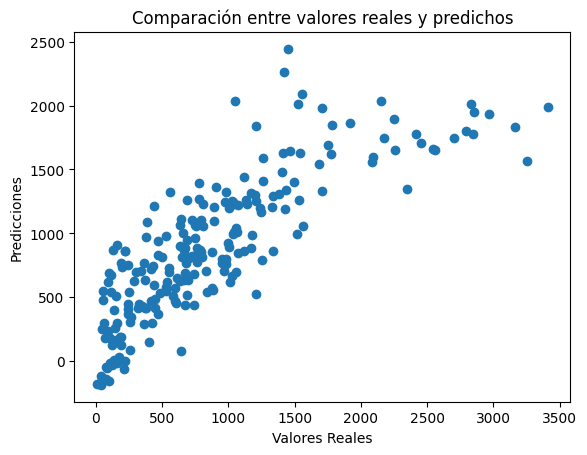

In [ ]:
# Genera predicciones
y_pred = model.predict(X_test)

# Calcula métrica MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# Calcula RMSE
import numpy as np
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Grafica valores reales vs predichos
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Comparación entre valores reales y predichos")
plt.show()

# Pregunta: ¿Qué información nos da el MSE sobre la calidad del modelo?
# Respuesta: El MSE (Error Cuadrático Medio) indica cuánto se equivocan en promedio las predicciones del modelo.
# Cuanto menor sea el MSE, mejor es el ajuste del modelo a los datos reales.

# Pregunta: ¿Qué información nos da el RMSE sobre la calidad del modelo?
# Respuesta: El RMSE es la raíz cuadrada del MSE y tiene las mismas unidades que la variable objetivo.
# Es más fácil de interpretar y también refleja el promedio de los errores de predicción.

# 7. Extensión / Retos

In [ ]:
# Entrena un modelo usando solo la variable 'temp'
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Redefine X con solo la columna 'temp'
X_temp = bike_data[['temp']]
y = bike_data['rentals']

# Divide los datos
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, y, test_size=0.3, random_state=0)

# Crea y entrena el modelo
model_temp = LinearRegression()
model_temp.fit(X_train_temp, y_train_temp)

# Predicciones y métricas
y_pred_temp = model_temp.predict(X_test_temp)
mse_temp = mean_squared_error(y_test_temp, y_pred_temp)
rmse_temp = np.sqrt(mse_temp)

print("MSE modelo con 'temp':", mse_temp)
print("RMSE modelo con 'temp':", rmse_temp)

# Comparación con modelo multivariable
y_pred_multi = model.predict(X_test)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("MSE modelo multivariable:", mse_multi)
print("RMSE modelo multivariable:", rmse_multi)

# Pregunta: ¿Cuál modelo es más preciso y por qué?
# Respuesta: El modelo multivariable es más preciso porque considera más factores que influyen en los alquileres,
# como la humedad, el viento, el día de la semana y si es festivo. Usar solo 'temp' limita la capacidad del modelo
# para capturar la complejidad real del comportamiento de los usuarios.

MSE modelo con 'temp': 374482.8022842907
RMSE modelo con 'temp': 611.9499998237525
MSE modelo multivariable: 168177.78386090606
RMSE modelo multivariable: 410.09484739619205
